# Hong Kong Market Support 香港市场支持 (HKEX)

QuantEval now supports the Hong Kong stock market! This notebook demonstrates how to:
1. Load HK stock data (e.g., Tencent 00700).
2. Load HK index data (e.g., Hang Seng Index ^HSI).
3. Apply `HKTransactionCost` which includes bilateral stamp duty, SFC levy, and HKEX trading fees.

QuantEval 现已支持港股市场！本 Notebook 演示：
1. 如何加载港股数据（示例：腾讯 00700）。
2. 如何加载香港指数（示例：恒生指数 ^HSI）。
3. 如何使用 `HKTransactionCost`（包含双边印花税、SFC 征费与港交所手续费）。

In [1]:
# Import required modules / 导入所需模块
from quanteval import DataLoader, Backtester, DualMAStrategy, HKTransactionCost

/root/miniconda3/lib/python3.13/site-packages/py_mini_racer/py_mini_racer.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Loading Data / 加载数据

We use `DataLoader.load_hk_stock()` for HKEX stocks (use 5-digit zero-padded symbols) and `DataLoader.load_hk_index()` for indices (via yfinance).

我们使用 `DataLoader.load_hk_stock()` 加载港股（请使用 5 位补零代码），使用 `DataLoader.load_hk_index()` 加载指数（通过 yfinance）。

In [2]:
# Initialize DataLoader (use cache to avoid repeated downloads) / 初始化 DataLoader（使用缓存以避免重复下载）
loader = DataLoader(use_cache=True)

# Load Tencent (00700) data for 2023 / 加载腾讯（00700）2023 年数据
stock_data = loader.load_hk_stock('00700', start_date='20230101', end_date='20231231')
print("Tencent (00700) Data:")
print(stock_data.head())

# Load Hang Seng Index (^HSI) / 加载恒生指数 (^HSI)
index_data = loader.load_hk_index('^HSI', start_date='20230101', end_date='20231231')
print("\nHang Seng Index (^HSI) Data:")
print(index_data.head())

Tencent (00700) Data:
             Open   High    Low  Close    Volume        Amount       Ret
Date                                                                    
2023-01-04  350.0  361.0  349.0  361.0  37429922  1.332286e+10  0.045771
2023-01-05  358.0  362.2  343.6  347.8  40803927  1.435026e+10 -0.036565
2023-01-06  353.6  359.4  346.8  349.4  27092487  9.537399e+09  0.004600
2023-01-09  355.0  362.4  351.6  362.0  28323733  1.016206e+10  0.036062
2023-01-10  365.0  365.8  357.0  362.4  19854116  7.160873e+09  0.001105

Hang Seng Index (^HSI) Data:
                    Open          High           Low         Close  \
Date                                                                 
2023-01-04  20319.980469  20793.109375  20233.390625  20793.109375   
2023-01-05  21295.869141  21396.089844  20962.400391  21052.169922   
2023-01-06  21220.890625  21282.710938  20862.769531  20991.640625   
2023-01-09  21295.939453  21470.689453  21216.919922  21388.339844   
2023-01-10  21370

## 2. Backtesting with HK Transaction Costs / 港股交易成本回测

The Hong Kong market has different transaction costs compared to A-shares. Notably, stamp duty is applied to **both** buy and sell trades (bilateral). `HKTransactionCost` handles this automatically.

港股与 A 股的交易成本不同，尤其是印花税在买卖双方均会征收（双边）。`HKTransactionCost` 会自动为你计算这些费用。

In [3]:
# Create strategy / 创建策略
strategy = DualMAStrategy(fast_window=10, slow_window=30)

# Set up transaction costs for HK / 设置港股交易成本
hk_costs = HKTransactionCost()

# Run Backtest / 运行回测
bt = Backtester(
    strategy=strategy,
    data=stock_data,
    transaction_costs=hk_costs,
    initial_capital=100000.0,
)
results = bt.run()

## 3. Results and Visualization / 结果与可视化

Let's inspect summary metrics and visualize the equity curve. The example keeps interactive plotting enabled by default — in CI we typically use static output.

查看回测汇总指标并可视化收益曲线。示例默认开启交互式绘图；在 CI 中我们通常使用静态输出以避免图形后端问题。

In [4]:
# Summary metrics / 汇总指标
print(results.summary())

total_return              -0.250515
annual_return             -0.259393
annual_volatility          0.154234
max_drawdown              -0.272912
max_drawdown_duration    211.000000
sharpe_ratio              -1.876324
sortino_ratio             -1.627064
calmar_ratio              -0.950466
num_trades                 5.000000
win_rate                   0.200000
profit_loss_ratio          0.323858
avg_trade_duration        19.200000
benchmark_return          -0.188462
alpha                     -0.063958
information_ratio         -0.420027
dtype: float64


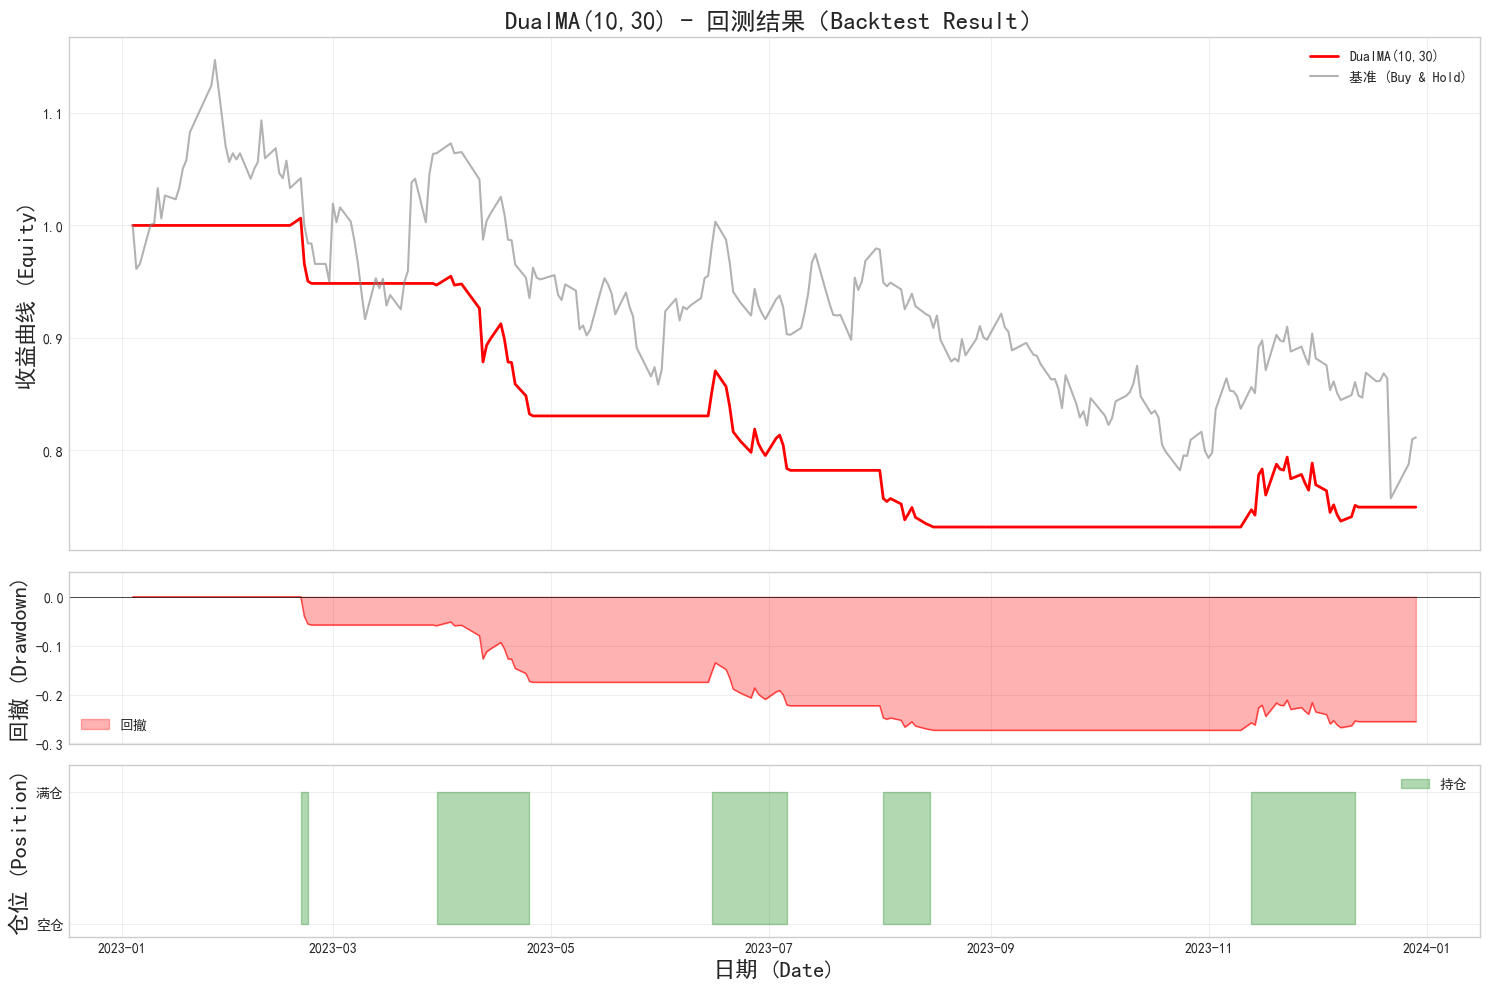

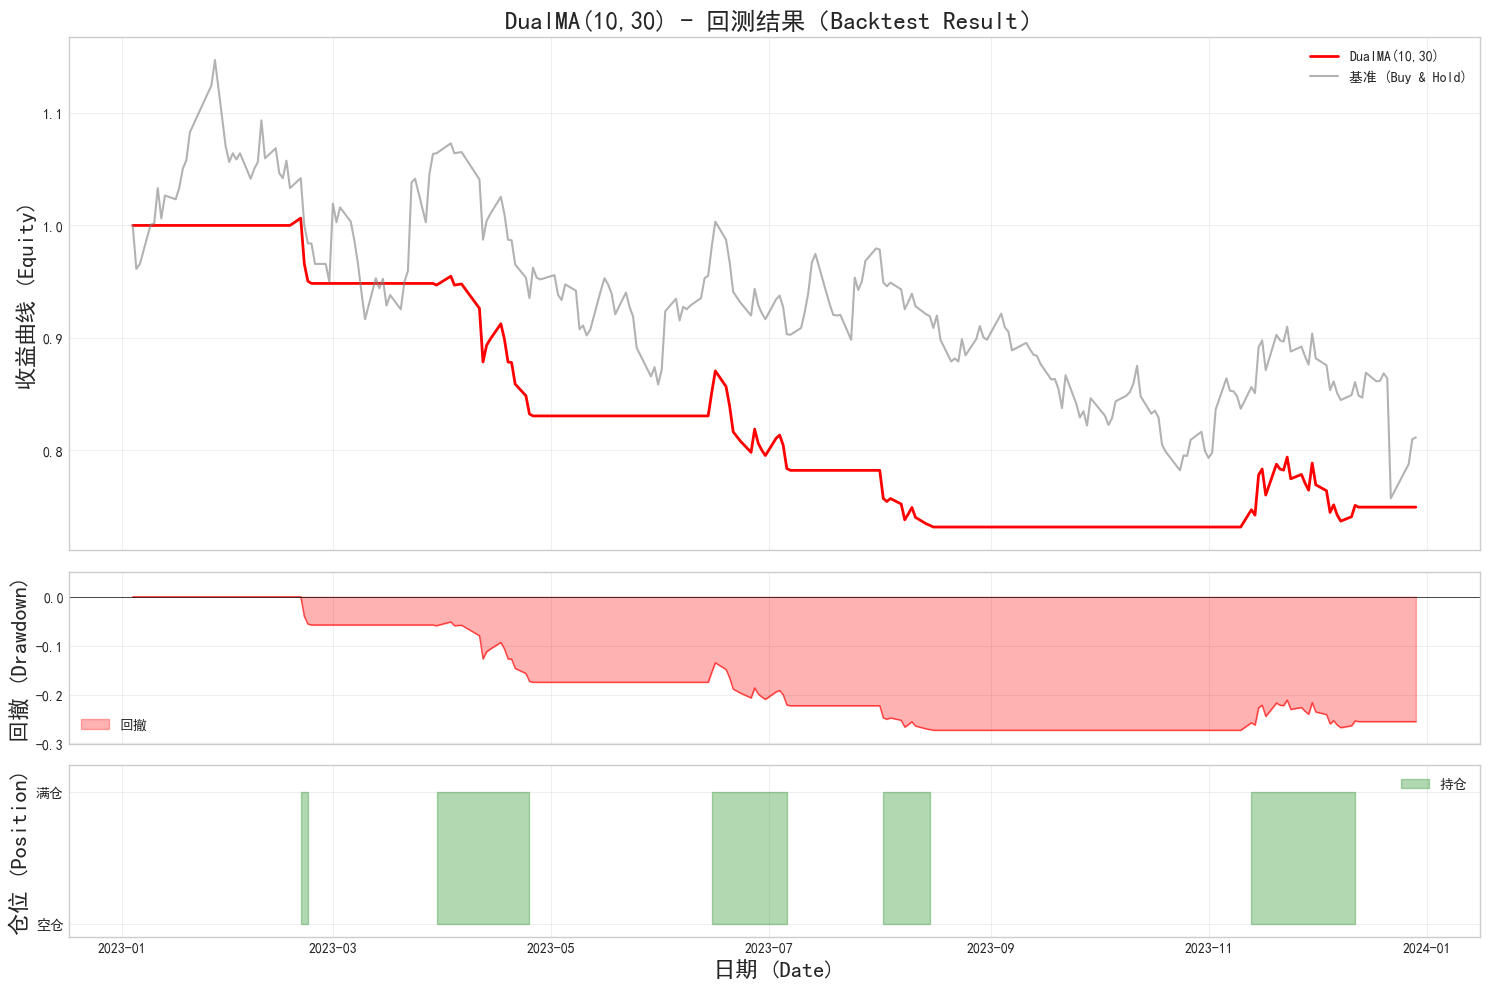

In [5]:
# Plot the equity curve (interactive plot) / 可视化收益曲线（交互式）
# For CI or static examples, set interactive=False if needed / 在 CI 或静态示例中可设置 interactive=False
results.plot()